In [15]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# 确保本地包可 import（在 repo 根目录 or 子目录里都能跑）
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "alpha_lab").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from alpha_lab.config import get_paths, ensure_dir
paths = get_paths()
ensure_dir(paths.data_raw_dir)


PosixPath('/home/linnnw/projects/alpha-lab/data/raw')

In [16]:
# 导入模块（核心代码已修复，无需 monkey patch）
import numpy as np
import pandas as pd

import alpha_lab.portfolio.rebalance as reb
import alpha_lab.backtest.engine as eng
import alpha_lab.metrics.drawdown as dd
from alpha_lab.utils.dates import parse_date, generate_rebalance_dates

# 注意：之前这里有大量 monkey patch 代码来修复以下问题：
# 1. _generate_rebalance_schedule_fixed - 现已在 rebalance.py 中修复
# 2. _simulate_portfolio_fixed - 现已在 engine.py 中修复（日期比较和边界条件）
# 3. _compute_drawdown_series_fixed - 现已在 drawdown.py 中修复
# 4. _compute_drawdown_metrics_fixed - 现已在 drawdown.py 中修复
# 
# 这些修复已合并到核心代码中，此 cell 现在只需要导入模块即可

In [17]:
USE_SYNTHETIC = False# 如果你有真实 CSV，改成 False
csv_path = paths.data_raw_dir / "random_sampled_stocks_adj_close.csv"


if USE_SYNTHETIC or not csv_path.exists():
    rng = np.random.default_rng(7)
    dates = pd.date_range("2022-01-03", periods=260, freq="B")
    tickers = ["AAA", "BBB", "CCC", "DDD", "EEE"]

    prices = pd.DataFrame(
        100 * np.exp(np.cumsum(rng.normal(0, 0.01, (len(dates), len(tickers))), axis=0)),
        index=dates,
        columns=tickers,
    )
    prices.index.name = "date"
    prices.reset_index().to_csv(csv_path, index=False)

    print("wrote", csv_path)
else:
    print("use existing", csv_path)


use existing /home/linnnw/projects/alpha-lab/data/raw/random_sampled_stocks_adj_close.csv


In [18]:
# 重新加载模块以确保使用最新修复的代码
import importlib
import sys

# 重新加载核心模块
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('alpha_lab'):
        try:
            importlib.reload(sys.modules[mod_name])
        except:
            pass

from alpha_lab.data.loader import load_prices, infer_tradable_mask
from alpha_lab.factors.momentum import momentum
from alpha_lab.factors.transform import winsorize
from alpha_lab.metrics.factor_diagnostics import (
    compute_forward_returns,
    compute_ic_series,
    compute_ic_stats,
)
from alpha_lab.portfolio.rebalance import generate_rebalance_schedule
from alpha_lab.portfolio.weighting import top_k_long_only, apply_weight_constraints

# 读取 CSV 头部,适配 Date/date
header = pd.read_csv(csv_path, nrows=0).columns
date_col = next((c for c in header if c.lower() == "date"), None)
if date_col is None:
    raise ValueError(f"CSV must have date column, got: {list(header)}")

tickers = [c for c in header if c != date_col]
dates = pd.read_csv(csv_path, usecols=[date_col], parse_dates=[date_col])[date_col]
start_ts = dates.min()
end_ts = dates.max()

# 使用 loader 读取价格 (date 对齐 + ffill 限制)
prices_loaded = load_prices(
    universe=tickers,
    start_date=start_ts,
    end_date=end_ts,
    field="close",
    source="csv",
    align_dates=True,
    csv_file=csv_path.name,
)

print(f"✓ Loaded prices: {prices_loaded.shape} (dates × tickers)")
print(f"  Date range: {prices_loaded.index.min().date()} to {prices_loaded.index.max().date()}")
print(f"  Tickers (first 5): {prices_loaded.columns.tolist()[:5]}")
print(f"  Sample prices:\n{prices_loaded.iloc[:3, :3]}")

# 动态可交易掩码 (价格可用性)
tradable_mask = infer_tradable_mask(prices_loaded, min_valid_price=0.0)

# 计算因子与权重
factor = momentum(prices_loaded, lookback=5, lag=1, method="log")
factor = winsorize(factor)
factor = factor.where(tradable_mask)

rebalance_dates = generate_rebalance_schedule(
    trading_calendar=prices_loaded.index,
    start_date=start_ts,
    end_date=end_ts,
    freq="M",
)

# 使用 reindex 处理日期对齐问题
factor_reb = factor.reindex(rebalance_dates).dropna(how="all")

# 加入 hysteresis/no-trade band + 约束
weights = top_k_long_only(factor_reb, k_pct=0.2, buffer_pct=0.05)
weights = apply_weight_constraints(
    weights,
    max_position_size=0.1,
    max_turnover=0.3,
)

print(f"\n✓ Factor shape: {factor.shape}")
print(f"✓ Rebalance dates: {len(rebalance_dates)} dates")
print(f"✓ Weights shape: {weights.shape}")
print(f"  Sample rebalance dates: {rebalance_dates[:3].tolist()}")

# IC (调仓日口径, 含执行延迟)
ic_horizon = 21
ic_delay = 1
fwd_returns = compute_forward_returns(prices_loaded, horizon=ic_horizon, delay=ic_delay)
fwd_returns = fwd_returns.where(tradable_mask).reindex(factor_reb.index)

ic_series = compute_ic_series(factor_reb, fwd_returns, method="spearman", min_obs=30)
ic_stats = compute_ic_stats(ic_series)
print(f"\n✓ IC stats: {ic_stats}")


2026-02-02 12:08:00 | INFO     | alpha_lab.data.loader | Loading close prices: 196 tickers, 2010-01-01 to 2025-12-31
2026-02-02 12:08:00 | INFO     | alpha_lab.data.loader | Loaded: 4174 days x 196 assets
✓ Loaded prices: (4174, 196) (dates × tickers)
  Date range: 2010-01-01 to 2025-12-31
  Tickers (first 5): ['COHU', 'BELFA', 'PSEC', 'CREG', 'PZZA']
  Sample prices:
                 COHU      BELFA      PSEC
2010-01-01        NaN        NaN       NaN
2010-01-04  12.009974  16.026287  1.787887
2010-01-05  11.514716  15.703946  1.801296
2026-02-02 12:08:00 | INFO     | alpha_lab.portfolio.rebalance | Generated 192 rebalance dates (freq=M)

✓ Factor shape: (4174, 196)
✓ Rebalance dates: 192 dates
✓ Weights shape: (192, 196)
  Sample rebalance dates: [Timestamp('2010-01-29 00:00:00'), Timestamp('2010-02-26 00:00:00'), Timestamp('2010-03-31 00:00:00')]

✓ IC stats: {'ic_mean': -0.01218897143873518, 'ic_std': 0.12481349250415238, 'ic_ir': -0.09765748232972224, 'ic_hit_rate': 0.439790575916

In [19]:
from alpha_lab.backtest.engine import run_backtest
from alpha_lab.config.backtest import BacktestConfig
from alpha_lab.metrics.summary import generate_backtest_summary

cfg = BacktestConfig(
    start_date=start_ts.date().isoformat(),
    end_date=end_ts.date().isoformat(),
    rebalance_freq="M",
    initial_cash=1_000_000.0,
    commission_bps=5,
    slippage_bps=5,
    price_field="close",
    max_turnover=0.3,
    rebalance_threshold=0.01,
    execution_delay_days=1,
)

result = run_backtest(weights=weights, prices=prices_loaded, config=cfg)
metrics = generate_backtest_summary(result, as_dataframe=False)

metrics


2026-02-02 12:08:01 | INFO     | alpha_lab.backtest.engine | Running backtest: 2010-01-01 to 2025-12-31, freq=M, initial_cash=1,000,000
2026-02-02 12:08:01 | INFO     | alpha_lab.backtest.engine | execution_delay_days=1: dropped 1 signals beyond end_date
2026-02-02 12:08:03 | INFO     | alpha_lab.backtest.engine | Backtest complete: 4174 days, final equity=6,319,535
2026-02-02 12:08:03 | INFO     | alpha_lab.metrics.summary | Generating metrics summary


{'total_return': np.float64(5.319534875970608),
 'cagr': np.float64(0.11776869114610622),
 'annualized_vol': np.float64(0.2075195595278372),
 'sharpe_ratio': np.float64(0.640553267441395),
 'win_rate': np.float64(0.5143747005270723),
 'best_day': np.float64(0.09946269878275027),
 'worst_day': np.float64(-0.11240582238621122),
 'n_periods': 4174,
 'max_drawdown': np.float64(0.41058393199093446),
 'avg_drawdown': np.float64(0.1309133174077114),
 'current_drawdown': np.float64(0.1866285395494301),
 'max_drawdown_duration': 1082,
 'turnover_avg': 0.28389581526916086,
 'turnover_median': 0.2849971160487769,
 'turnover_max': 0.30009002700810256,
 'n_trade_days': 191.0,
 'turnover_total': 179.25846661622285,
 'cost_est_total': 179258.46661622287,
 'cost_est_pct': 0.17925846661622286,
 'holdings_avg': 179.6272160996646,
 'holdings_max': 196.0,
 'hhi_avg': 0.008978723441158938,
 'hhi_max': 0.0287854373533487}

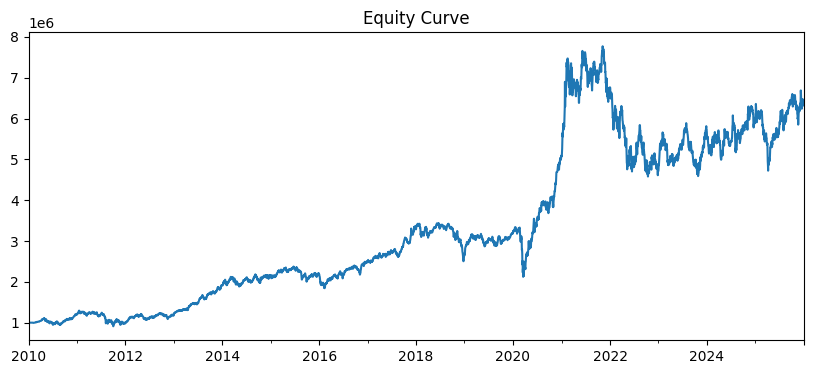

In [20]:
import matplotlib.pyplot as plt

result.equity_curve.plot(figsize=(10, 4), title="Equity Curve")
plt.show()
